**Purpose of script:** Loads trained model (best one from tuning) and creates DPA prediction ensemble.

Former notebook name: load_tuned_jointly_trained_model.ipynb

In [1]:
#import create_models as cm
#encoder = cm.create_models()


device: cuda
#######################
Encoder INITIALISATION
input_layer.layer1.0.weight: torch.Size([50, 648])
input_layer.layer1.0.bias: torch.Size([50])
input_layer.layer1.1.weight: torch.Size([50])
input_layer.layer1.1.bias: torch.Size([50])
input_layer.layer1.1.running_mean: torch.Size([50])
input_layer.layer1.1.running_var: torch.Size([50])
input_layer.layer1.1.num_batches_tracked: torch.Size([])
input_layer.layer2.0.weight: torch.Size([50, 50])
input_layer.layer2.0.bias: torch.Size([50])
input_layer.layer2.1.weight: torch.Size([50])
input_layer.layer2.1.bias: torch.Size([50])
input_layer.layer2.1.running_mean: torch.Size([50])
input_layer.layer2.1.running_var: torch.Size([50])
input_layer.layer2.1.num_batches_tracked: torch.Size([])
input_layer.layer3.weight: torch.Size([50, 648])
input_layer.layer3.bias: torch.Size([50])
inter_layer.0.layer1.0.weight: torch.Size([50, 50])
inter_layer.0.layer1.0.bias: torch.Size([50])
inter_layer.0.layer1.1.weight: torch.Size([50])
inter_layer.0.

In [1]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import os
import random
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from torchvision.utils import make_grid
from engression.models import StoNet, StoLayer
from engression.loss_func import energy_loss, energy_loss_two_sample
import argparse
import json
import xarray as xr
import torch.nn as nn
from sklearn.manifold import TSNE


import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shutil
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
#import pca_encoder as pcae
import utils as ut

In [2]:
#############
### Seeds ###
#############
random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

##################
### Cuda Setup ###
##################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

###################
### Build Model ###
###################
# define model parameters 
encoder="learnable"
latent_dim=50
in_dim=648
hidden_dim=50
num_layers=6
noise_dim_dec=5

in_dim_lm=1001
num_layers_lm=2
hidden_dim_lm=50
noise_dim_lm=20




out_act = None
resblock=True

bn=True #False
lambd=0.5
bs=128
epochs=300


# Encoder
if encoder == "PCA":
    pca, pcs = pcae.get_PC(ds_train)
    eofs_torch_first = pca.components_[:latent_dim, :] # # take only the first latent_dim PCs, pca.components_ has shape: (n_components_total, n_features) = (modes, space)
    
    # "encode" by projecting onto PCs
    def model_enc(x, eofs=eofs_torch_first):
        teofs = ((torch.from_numpy(eofs)).T).to(device)
        return torch.matmul(x, teofs)
        
    
elif encoder == "learnable":
    model_enc = StoNet(in_dim=in_dim,
                       out_dim=latent_dim,
                       num_layer=num_layers,
                       hidden_dim=hidden_dim,
                       noise_dim=0,
                       add_bn=bn,
                       out_act=out_act,
                       resblock=resblock).to(device)
# Decoder
model_dec = StoNet(in_dim=latent_dim,
                   out_dim=in_dim,
                   num_layer=num_layers,
                   hidden_dim=hidden_dim,
                   noise_dim=noise_dim_dec,
                   add_bn=bn,
                   out_act=out_act,
                   resblock=resblock).to(device)
# Latent Map
model_pred = StoNet(in_dim=in_dim_lm,
                    out_dim=latent_dim, 
                    num_layer=num_layers_lm,
                    hidden_dim=hidden_dim_lm, 
                    noise_dim=noise_dim_lm,
                    add_bn=bn, 
                    out_act=out_act, 
                    resblock=resblock).to(device)

device: cpu


In [3]:
#################
### Load Data ###
#################
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
    settings = json.load(file)
  
# Save to a new file for logging
#with open(f"used_settings.json", "w") as f:
#    json.dump(settings, f, indent=4)

# Load temperature data
ds = xr.open_dataset(settings['dataset_trefht'])
print("Dataset:", settings['dataset_trefht'])

# set train/test split
ds_train = ds.isel(time=slice(0, 128000)) #4769 * 80
ds_test = ds.isel(time=slice(-64000, 476900)) #4769 * 80

# transform to torch tensors
x_tr = ut.data_to_torch(ds_train, "TREFHT")
x_te = ut.data_to_torch(ds_test, "TREFHT")

# load Z500
ds_z500_pre = xr.open_dataset(settings['dataset_z500'])
ds_z500, _, _ = ut.standardize_numpy(ds_z500_pre.pseudo_pcs.values)
print("z500 shape", ds_z500.shape)
z500 = torch.from_numpy(ds_z500)
print("z500 shape", z500.shape)


z500_train = z500[:int(128000),:]
z500_test = z500[int(-64000):,:]

# remove NaNs from data
x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)
x_te_reduced, mask_x_te = ut.remove_nan_columns(x_te)

# create data loader Temperature
train_dataset = TensorDataset(z500_train, x_tr_reduced)
train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=False)
print(f"Number of batches: {len(train_loader)}")

# create test loader Temperature
test_dataset = TensorDataset(z500_test, x_te_reduced)
test_loader_in = DataLoader(test_dataset, batch_size=bs, shuffle=False)
print(f"Number of batches: {len(test_loader_in)}")

Dataset: /work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/europe_10percent_masked_stacked_TREFHT_JJA.nc
torch.Size([128000, 1024])
torch.Size([64000, 1024])
z500 shape (476900, 1001)
z500 shape torch.Size([476900, 1001])
Number of batches: 1000
Number of batches: 500


In [30]:
z500_test

tensor([[-1.2082,  1.1906,  0.0358,  ...,  0.3012,  1.0583, -0.4020],
        [-0.2408,  0.8740, -0.5983,  ..., -1.1212,  2.5108, -0.3938],
        [-0.8946,  0.3432,  0.5073,  ..., -1.7083,  1.4080, -0.4043],
        ...,
        [ 0.1532, -1.6537,  0.5919,  ..., -0.2664,  1.7772,  2.7999],
        [ 0.4789, -1.5022,  0.3054,  ..., -0.4939, -0.1881,  2.7889],
        [ 0.8664, -1.4883, -0.3215,  ...,  0.1475,  0.7248,  2.7818]])

In [6]:
# Path to the saved model file
encoder_path = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_bs128/model_enc_100.pt"
decoder_path = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_bs128/model_dec_100.pt"
lm_path = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/_50_6_50_5_1001_20_2_50_encoderislearnable_lambda0.5_bs128/model_pred_100.pt"

# Load the state dict from the .pt file
# using GPU
#enc_dict = torch.load(encoder_path)
#dec_dict = torch.load(decoder_path)
#lm_dict = torch.load(lm_path)

# using CPU
enc_dict = torch.load(encoder_path, map_location=torch.device('cpu'))
dec_dict = torch.load(decoder_path, map_location=torch.device('cpu'))
lm_dict = torch.load(lm_path, map_location=torch.device('cpu'))


# Load the state dict into the internal DPA model
#dpa.model.load_state_dict(state_dict)
model_enc.load_state_dict(enc_dict)
model_dec.load_state_dict(dec_dict)
model_pred.load_state_dict(lm_dict)

<All keys matched successfully>

In [7]:
if encoder == "learnable":
    model_enc.eval()
model_dec.eval()
model_pred.eval()

x_te = z500_test #test_batch[0].to(device)
y_te = x_te_reduced #test_batch[1].to(device)


# "save latent space"
#encoded_sample = model_enc(y_te)
#torch.save(encoded_sample, f"{save_dir}epoch_{epoch_idx}_test_sample_latent_space.pt")

#rec1_te = model_dec(encoded_sample)
#rec2_te = model_dec(encoded_sample)

gen1_te = model_dec(model_pred(x_te.to(device)))
gen2_te = model_dec(model_pred(x_te.to(device)))
gen3_te = model_dec(model_pred(x_te.to(device)))

#loss_te_rec_pre = energy_loss_two_sample(y_te, rec1_te, rec2_te, beta=beta)
#loss_te_pred_pre = energy_loss_two_sample(y_te, gen1_te, gen2_te, beta=beta)

In [14]:
#for i in range(4,104):
#    print(i)
#    gen_te = model_dec(model_pred(x_te.to(device)))
#    torch.save(gen_te, f"/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen{i}_te.pt")

    

4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98


OutOfMemoryError: CUDA out of memory. Tried to allocate 160.00 MiB. GPU 0 has a total capacity of 23.50 GiB of which 67.62 MiB is free. Including non-PyTorch memory, this process has 20.75 GiB memory in use. Process 883478 has 2.66 GiB memory in use. Of the allocated memory 20.13 GiB is allocated by PyTorch, and 369.82 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [8]:
y_te_from_restored = ut.restore_nan_columns(y_te, mask_x_te)
gen1_te_from_restored = ut.restore_nan_columns(gen1_te, mask_x_te)
gen2_te_from_restored = ut.restore_nan_columns(gen2_te, mask_x_te)
gen3_te_from_restored = ut.restore_nan_columns(gen3_te, mask_x_te)

#rec1_te_from_restored = ut.restore_nan_columns(rec1_te, mask_x_te)
#rec2_te_from_restored = ut.restore_nan_columns(rec2_te, mask_x_te)

In [13]:
#torch.save(y_te, "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/y_te.pt")
#torch.save(gen1_te, "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen1_te.pt")
#torch.save(gen2_te, "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen2_te.pt")
#torch.save(gen3_te, "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen3_te.pt")

#torch.save(y_te_from_restored, "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/y_te_from_restored.pt")
#torch.save(gen1_te_from_restored, "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen1_te_from_restorered.pt")
#torch.save(gen2_te_from_restored, "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen2_te_from_restorered.pt")
#torch.save(gen3_te_from_restored, "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen3_te_from_restorered.pt")

gen1_te_from_restored.shape

torch.Size([64000, 1024])

In [7]:
nrgy_loss = energy_loss_two_sample(y_te.to(device), gen1_te, gen2_te, beta=1)
nrgy_loss

tensor([21.2592, 39.4998, 36.4811], grad_fn=<CatBackward0>)

In [9]:
### convert predictions to xarray
y_te_xr = ut.torch_to_dataarray(y_te_from_restored, ds, lat_dim=32, lon_dim=32, name="TREFHT")
gen1_xr = ut.torch_to_dataarray(gen1_te_from_restored, ds, lat_dim=32, lon_dim=32, name="TREFHT")
gen2_xr = ut.torch_to_dataarray(gen2_te_from_restored, ds, lat_dim=32, lon_dim=32, name="TREFHT")
gen3_xr = ut.torch_to_dataarray(gen3_te_from_restored, ds, lat_dim=32, lon_dim=32, name="TREFHT")
gen3_xr

<xarray.DataArray 'TREFHT' (lat: 32, lon: 32, time: 64000)> Size: 262MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [-0.5032488 , -1.8187451 , -2.7136178 , ...,  9.940544  ,
         11.056036  , 13.706165  ],
        [-1.0110673 , -1.4801931 , -2.8379843 , ..., 10.347064  ,
         11.056541  , 13.55766   ],
        [-0.77523524, -1.6070535 , -2.461279  , ...,  9.568765  ,
         11.194502  , 14.334474  ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [-0.5494672 , -1.7187947 , -2.9441562 , ..., 10.049563  ,
         10.6398735 , 13.1568165 ],
        [-0.64767027, -1.6765251 , -2.5791295 , ..., 10.52387   ,
         11.724475  , 14.13614   ],
        [-0.8163284 , -1.7480376 , -2.6647213 , ...,  9.976847  ,
         11.826117  , 14.685565  ]]], shape=(32, 32, 64000), dtype=float32)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) int64 512kB 0 1 2 3 4 5 ... 63995 63996 63997 63998 63999

In [11]:
# save dataarrays
#y_te_xr.to_netcdf("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/y_te_xr.nc")
#gen1_xr.to_netcdf("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen1_xr.nc")
#gen2_xr.to_netcdf("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen2_xr.nc")
#gen3_xr.to_netcdf("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_model3_tuning1/gen3_xr.nc")

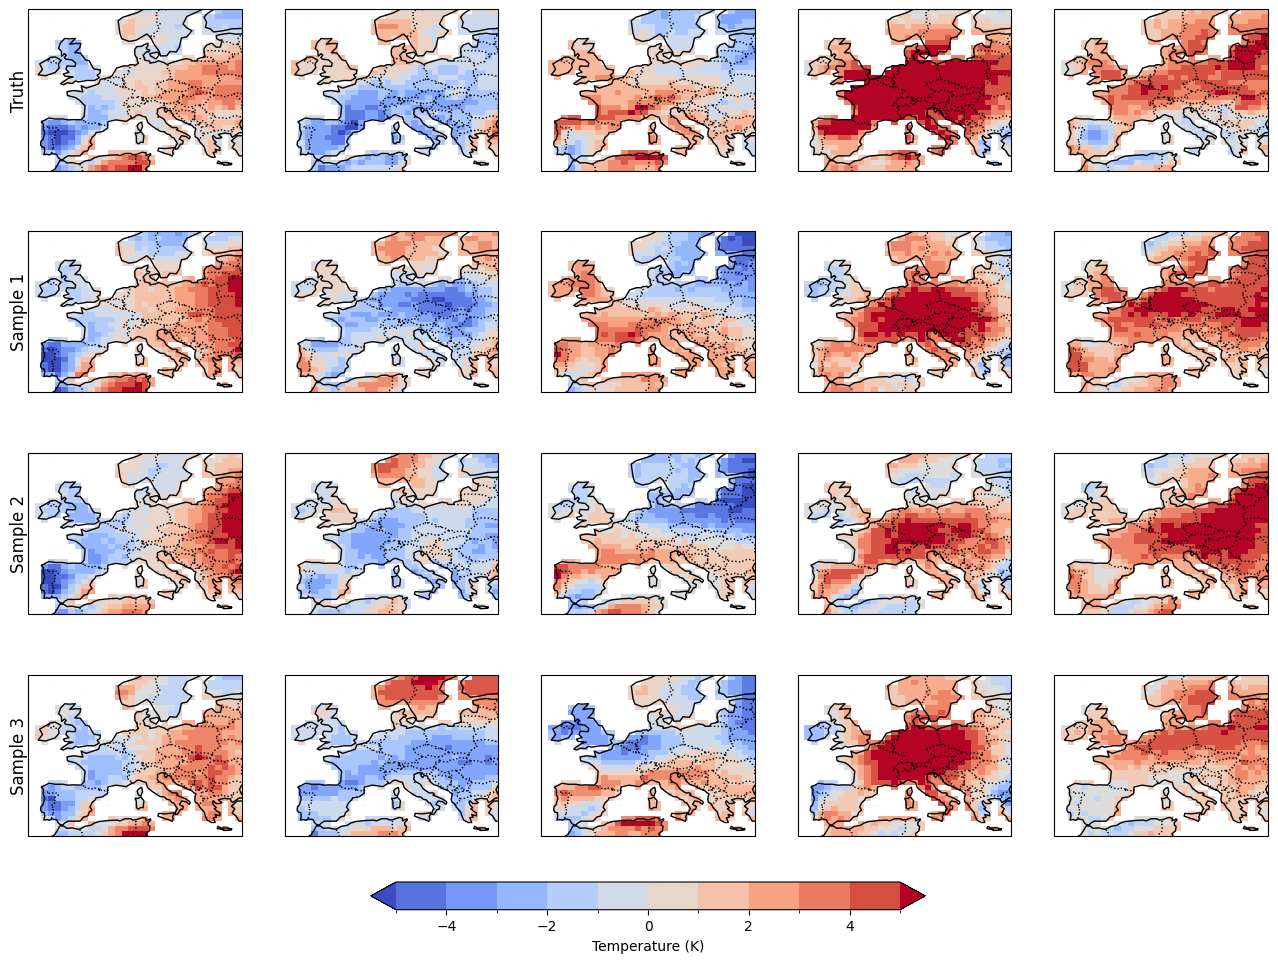

In [16]:
############
### PLOT ###
############
timesteps=[15, 42, 60, 94, 110]
fig, axs = plt.subplots(nrows=4, ncols=5, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()  # Flatten for easy indexing
#print(axs)
list_of_dataarrays_re = [gen1_xr, gen2_xr, gen3_xr]
for i, (ax, t) in enumerate(zip(axs, timesteps)):
    if i ==0:
        ut.plot_temperature_panel(axs[0], y_te_xr.isel(time=t), vmax_shared=5, sample_nr = "Truth")
        ut.plot_temperature_panel(axs[5], list_of_dataarrays_re[0].isel(time=t), vmax_shared=5, sample_nr = "Sample 1")
        ut.plot_temperature_panel(axs[10], list_of_dataarrays_re[1].isel(time=t), vmax_shared=5, sample_nr = "Sample 2")
        ut.plot_temperature_panel(axs[15], list_of_dataarrays_re[2].isel(time=t), vmax_shared=5, sample_nr = "Sample 3")
        
    else:
        ut.plot_temperature_panel(ax, y_te_xr.isel(time=t), vmax_shared=5)
        ut.plot_temperature_panel(axs[i+5], list_of_dataarrays_re[0].isel(time=t), vmax_shared=5)
        ut.plot_temperature_panel(axs[i+10], list_of_dataarrays_re[1].isel(time=t), vmax_shared=5)
        ut.plot_temperature_panel(axs[i+15], list_of_dataarrays_re[2].isel(time=t), vmax_shared=5)
        

# Optional: Add a colorbar
cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='horizontal', fraction=0.03, pad=0.05)
cbar.set_label('Temperature (K)')

plt.savefig(f"latent_map_decoded_samples_tac.pdf", format='pdf')
plt.show()

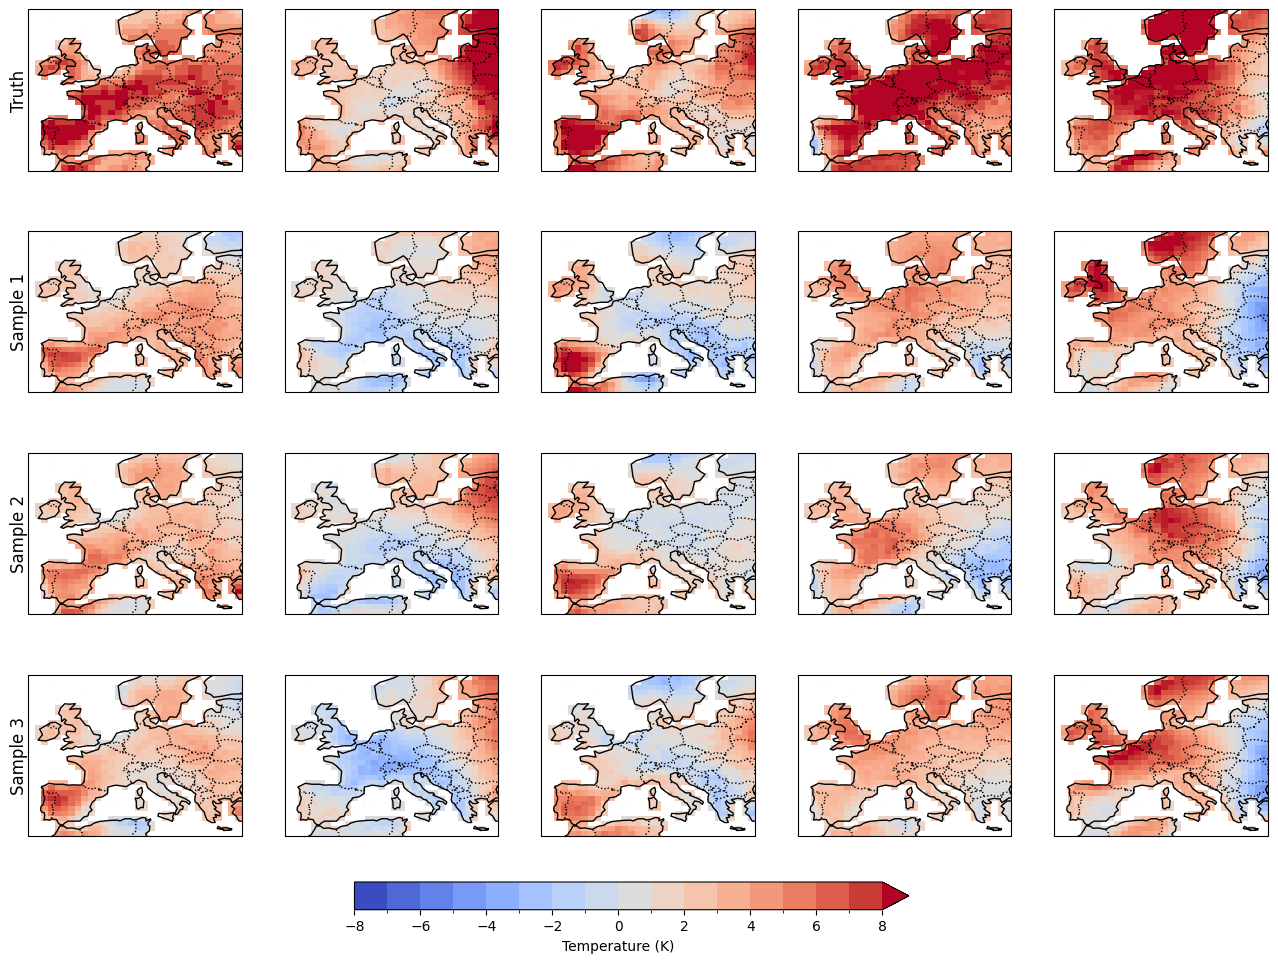

In [36]:
# Counterfactuals
#  set fGMT to zero
x_te_cf = x_te.clone()
x_te_cf[:, -1] = 0

gen1_te_cf = model_dec(model_pred(x_te_cf.to(device)))
gen2_te_cf = model_dec(model_pred(x_te_cf.to(device)))
gen3_te_cf = model_dec(model_pred(x_te_cf.to(device)))

gen1_te_from_restored_cf = ut.restore_nan_columns(gen1_te_cf, mask_x_te)
gen2_te_from_restored_cf = ut.restore_nan_columns(gen2_te_cf, mask_x_te)
gen3_te_from_restored_cf = ut.restore_nan_columns(gen3_te_cf, mask_x_te)

gen1_xr_cf = ut.torch_to_dataarray(gen1_te_from_restored_cf, ds, lat_dim=32, lon_dim=32, name="TREFHT")
gen2_xr_cf = ut.torch_to_dataarray(gen2_te_from_restored_cf, ds, lat_dim=32, lon_dim=32, name="TREFHT")
gen3_xr_cf = ut.torch_to_dataarray(gen3_te_from_restored_cf, ds, lat_dim=32, lon_dim=32, name="TREFHT")

############
### PLOT ###
############
timesteps=[63500, 63505, 63510, 63900, 63905]
fig, axs = plt.subplots(nrows=4, ncols=5, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()  # Flatten for easy indexing
#print(axs)
list_of_dataarrays_re_cf = [gen1_xr_cf, gen2_xr_cf, gen3_xr_cf]
for i, (ax, t) in enumerate(zip(axs, timesteps)):
    if i ==0:
        ut.plot_temperature_panel(axs[0], y_te_xr.isel(time=t), vmax_shared=5, levels = np.linspace(-8,8, 17), sample_nr = "Truth")
        ut.plot_temperature_panel(axs[5], list_of_dataarrays_re_cf[0].isel(time=t), vmax_shared=5, levels = np.linspace(-8,8), sample_nr = "Sample 1")
        ut.plot_temperature_panel(axs[10], list_of_dataarrays_re_cf[1].isel(time=t), vmax_shared=5, levels = np.linspace(-8,8), sample_nr = "Sample 2")
        ut.plot_temperature_panel(axs[15], list_of_dataarrays_re_cf[2].isel(time=t), vmax_shared=5, levels = np.linspace(-8,8), sample_nr = "Sample 3")
        
    else:
        ut.plot_temperature_panel(ax, y_te_xr.isel(time=t), vmax_shared=5, levels = np.linspace(-8,8))
        ut.plot_temperature_panel(axs[i+5], list_of_dataarrays_re_cf[0].isel(time=t), vmax_shared=5, levels = np.linspace(-8,8))
        ut.plot_temperature_panel(axs[i+10], list_of_dataarrays_re_cf[1].isel(time=t), vmax_shared=5, levels = np.linspace(-8,8))
        ut.plot_temperature_panel(axs[i+15], list_of_dataarrays_re_cf[2].isel(time=t), vmax_shared=5, levels = np.linspace(-8,8))
        

# Optional: Add a colorbar
cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='horizontal', fraction=0.03, pad=0.05)
cbar.set_label('Temperature (K)')

plt.savefig(f"latent_map_decoded_samples_tac_cf.pdf", format='pdf')
plt.show()

In [17]:
x_te.shape

torch.Size([64000, 1001])

In [27]:
# timesteps=[15, 42, 60, 94, 110]

print(x_te[15,-5:1001])
print(x_te[42,-5:1001])
print(x_te[60,-5:1001])
print(x_te[94,-5:1001])
print(x_te[110,-5:1001])

tensor([ 0.3506, -1.2548, -0.5963,  0.0757, -0.4195])
tensor([-0.5100,  0.6070, -0.0709, -1.1005, -0.2974])
tensor([ 0.7199, -1.4923, -1.0295,  0.8497, -0.2875])
tensor([ 0.0326, -0.2447, -0.4880, -1.1874, -0.2532])
tensor([-0.7187,  1.3856, -0.8012,  0.4460, -0.2151])


In [28]:
print(x_te[63800,-5:1001])

tensor([ 0.4401,  1.2223,  0.3612, -0.0663,  2.3707])
